# Trabajo Práctico 1: White Patch e Histogramas

Integrantes:
- Lucia T. Capon Paul
- Leandro Britez

## Parte 1: Algoritmo White Patch

El algoritmo White Patch es una técnica de balance de blancos que asume que el píxel más brillante de la imagen debería ser blanco. Al normalizar los canales R, G y B basándose en sus valores máximos, podemos compensar las diferencias de color producidas por la iluminación.

1. Implementar el algoritmo White Patch para librarnos de las diferencias de color de iluminación.
2. Mostrar los resultados obtenidos y analizar las posibles fallas (si es que las hay) en el caso de White patch.

In [14]:
import numpy as np
import cv2 as cv

%matplotlib inline
import matplotlib.pyplot as plt

### 1. Implementar el algoritmo White Patch

In [15]:
def white_patch_max(image):
    """
    Implementa el algoritmo White Patch normalizando por el máximo de cada canal.
    """
    # Aplanar la imagen a (num_píxeles, num_canales)
    pixels = image.reshape(-1, image.shape[-1])

    # Máximo por canal R, G, B
    illum = pixels.max(axis=0)

    # eVITAMOS división por cero si algún canal está completamente en 0
    illum_0 = np.where(illum == 0, 1, illum)

    # Normalizar cada canal y escalar al rango 0-255
    balanced = image / illum_0
    scaled = balanced * 255.0
    scaled = np.clip(scaled, 0, 255)

    return scaled.astype(np.uint8)


def white_patch_percentile(image, percentile):
    """
    Implementa White Patch usando un percentil en lugar del máximo absoluto.
    """
    pixels = image.reshape(-1, image.shape[-1])

    illum = np.percentile(pixels, percentile, axis=0)
    illum_0 = np.where(illum == 0, 1, illum)

    balanced = image / illum_0
    scaled = balanced * 255.0

    # Normalizar en base al valor máximo después de usar el percentil
    max_val = scaled.max()
    if max_val == 0:
        max_val = 1

    # Escalar al rango 0-255
    scaled = (scaled / max_val) * 255.0
    scaled = np.clip(scaled, 0, 255)

    return scaled.astype(np.uint8)


def create_image(image, image_path, name):
    """
    Guarda `image` junto a `image_path` original usando un sufijo `_name`.
    - `image_path` puede ser `str` o `Path`.
    Ej: image.jpg -> image_white_patched.jpg
    """
    from pathlib import Path

    p = Path(image_path)
    out_path = p.with_name(f"{p.stem}_{name}{p.suffix}")

    # cv2.imwrite acepta rutas como strings
    cv.imwrite(str(out_path), image)


def white_patch(image_path, percentile=100, save_image=False):
    """
    Lee la imagen, aplica White Patch (max) y opcionalmente
    la variante por `percentile`, guarda resultados y los muestra.

    - `image_path`: ruta a la imagen (str o Path)
    - `percentile`: si <100 también se calcula y muestra la versión por percentil
    - `save_image`: si True guarda los resultados junto al archivo original
    """
    # Leer imagen desde disco
    img = cv.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {image_path}")

    # Aplicar corrección por máximo
    patched = white_patch_max(img)

    # Aplicar corrección por percentil si se solicita
    patched_percentile = None
    if percentile < 100:
        patched_percentile = white_patch_percentile(img, percentile)

    # Guardado opcional
    if save_image:
        create_image(patched, image_path, "white_patched")
        if patched_percentile is not None:
            create_image(patched_percentile, image_path, f"white_patched_percentile_{percentile}")

    # Preparar visualización
    images = 2 if patched_percentile is None else 3
    height, width = img.shape[:2]

    # Elegir disposición de subplots según orientación de la imagen
    if width > height:
        fig, axes = plt.subplots(images, 1, figsize=(6, 4 * images))
    else:
        fig, axes = plt.subplots(1, images, figsize=(4 * images, 6))

    # Asegurar que `axes` sea indexable como arreglo
    if images == 2:
        axes0, axes1 = axes
    else:
        axes0, axes1, axes2 = axes

    # Mostrar original
    axes0.set_title("Original")
    axes0.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    axes0.axis('off')

    # Mostrar white patch (max)
    axes1.set_title("White patched (max)")
    axes1.imshow(cv.cvtColor(patched, cv.COLOR_BGR2RGB))
    axes1.axis('off')

    # Si existe, mostrar la versión con percentil
    if patched_percentile is not None:
        axes2.set_title(f"White patched (percentile={percentile})")
        axes2.imshow(cv.cvtColor(patched_percentile, cv.COLOR_BGR2RGB))
        axes2.axis('off')

    plt.tight_layout()
    plt.show()


### 2. Mostrar resultados y analizar fallas

Se cargan las imágenes de la carpeta `white_patch` y aplicamos el algoritmo.

white patching - test_blue.png


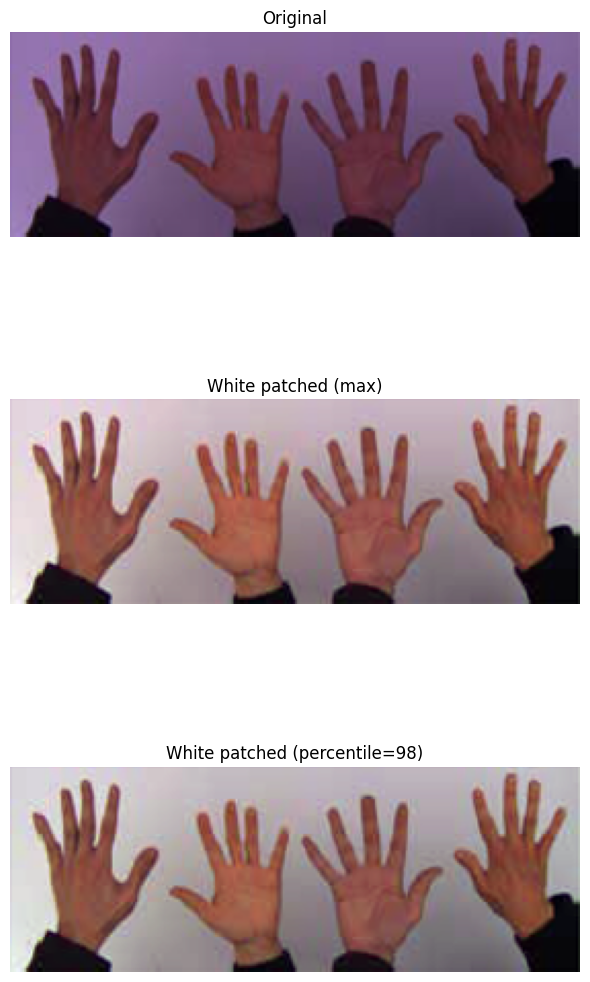

white patching - test_green.png


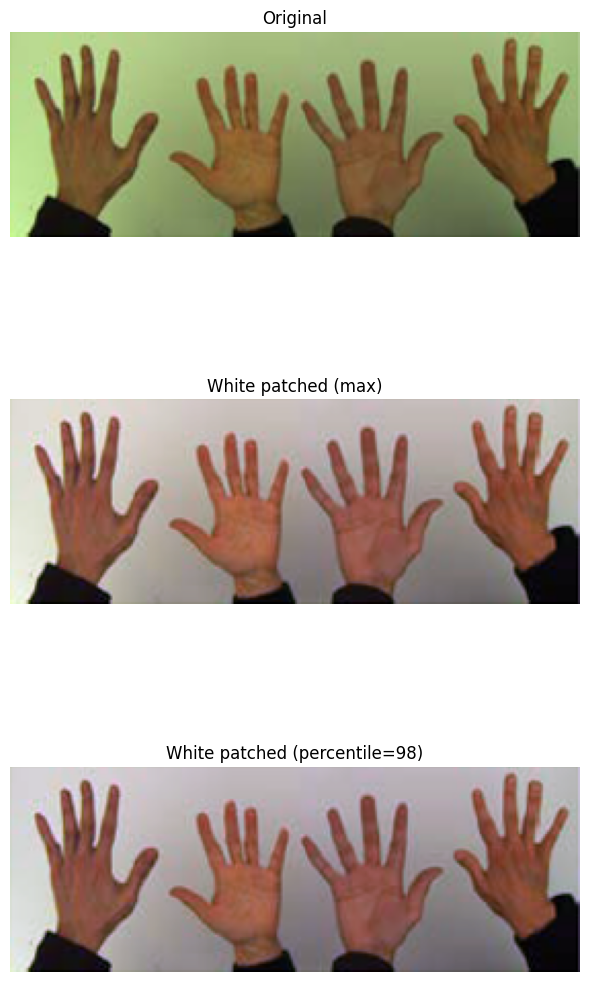

white patching - test_red.png


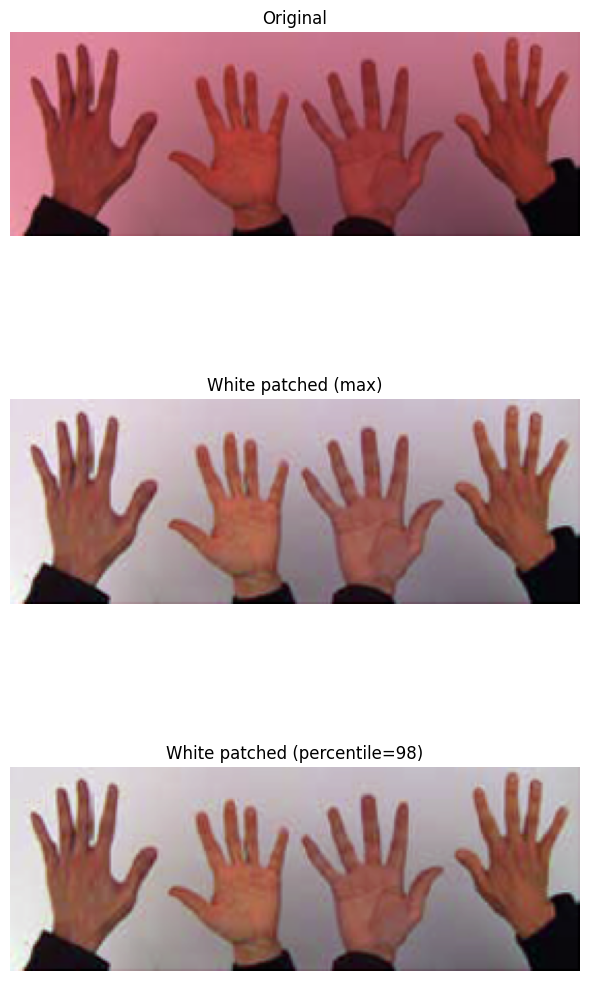

white patching - wp_blue.jpg


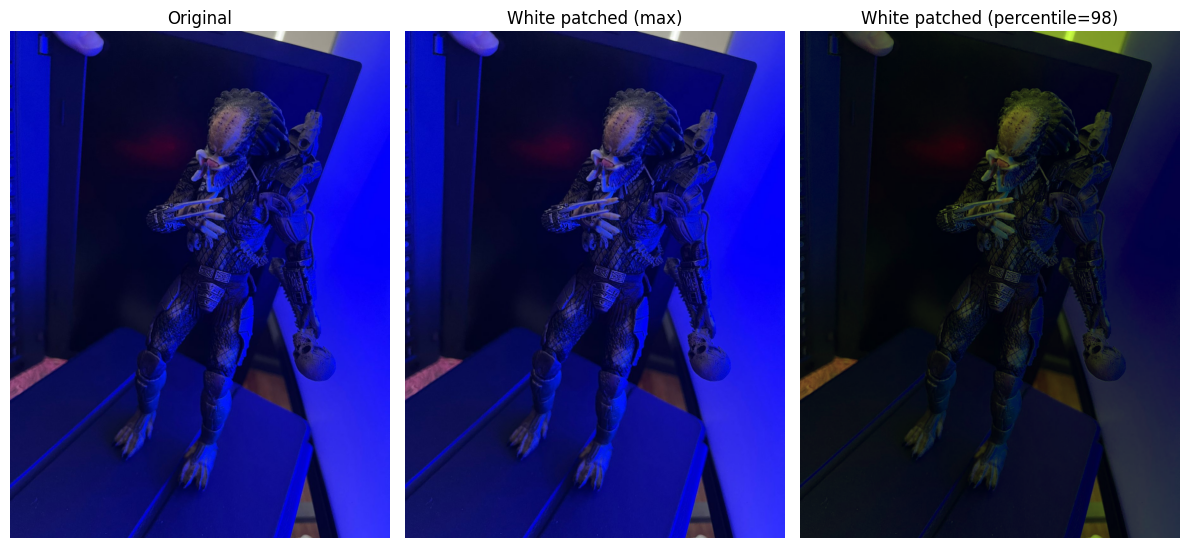

white patching - wp_green.png


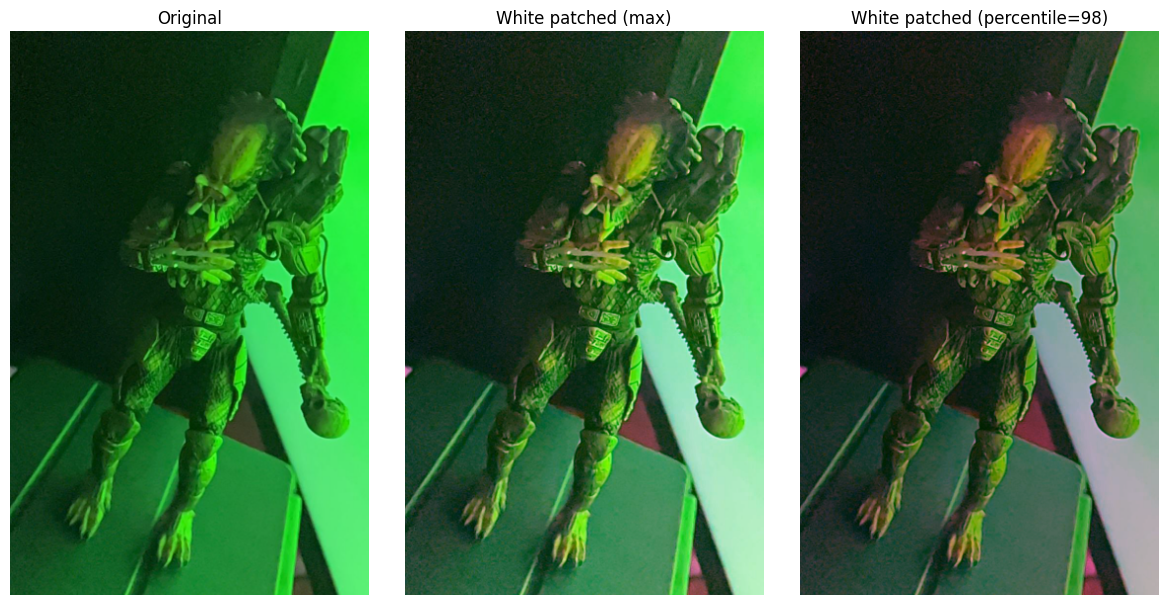

white patching - wp_green2.jpg


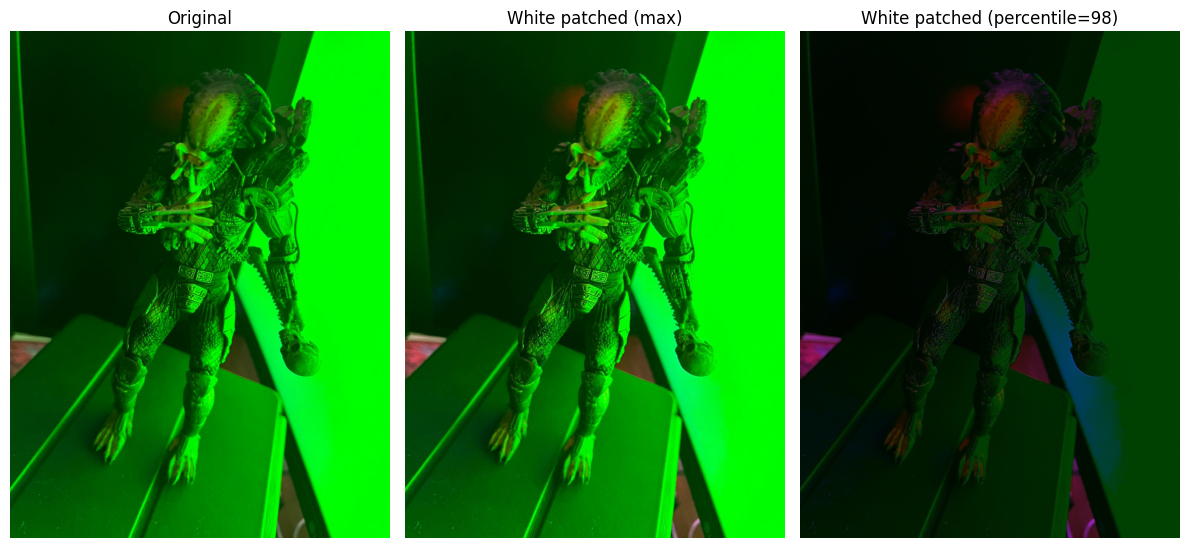

white patching - wp_red.png


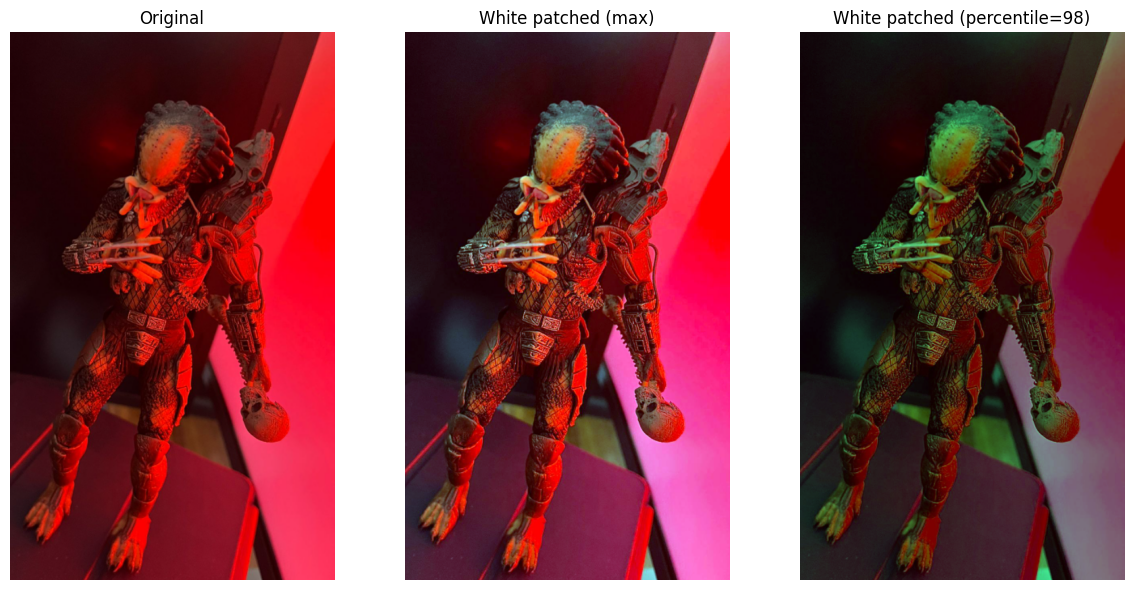

white patching - wp_red2.jpg


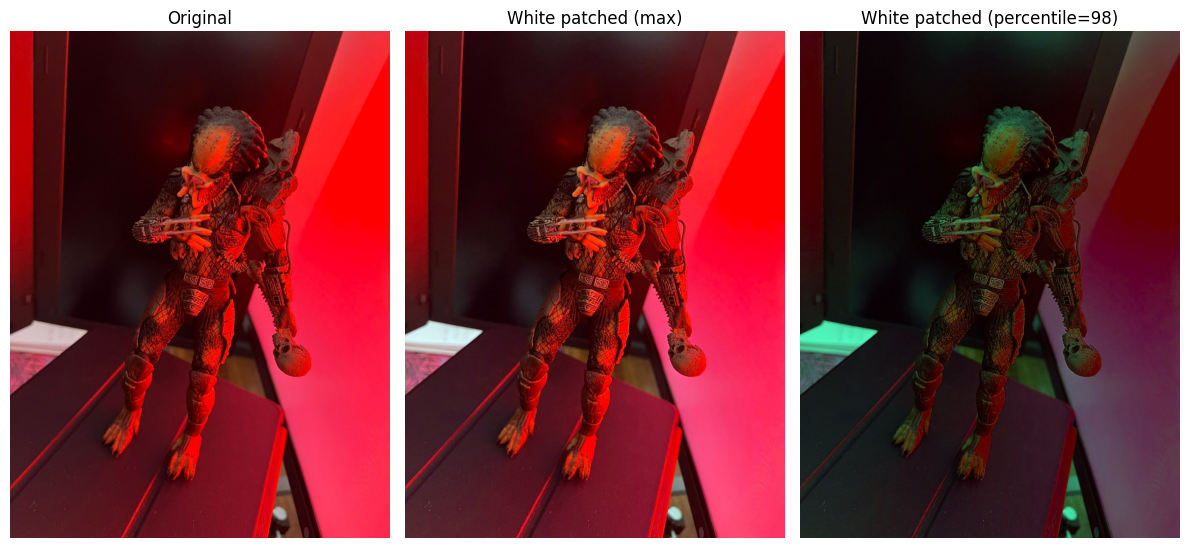

In [17]:
from pathlib import Path

# Procesar las imágenes de la carpeta 'white_patch' y aplicar White Patch a cada una:
folder = Path('white_patch')
images = sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in ('.png', '.jpg', '.jpeg')])

for file in images:

    print(f"white patching - {file.name}")

    white_patch(str(file), percentile=98, save_image=True)


En las imágenes de las manos se aprecia que el algoritmo de white‑patch logra recuperar bastante el color original de la imagen, lo que implica que dentro de la imagen original se encuentra un píxel lo suficientemente brillante por canal como para usarlo de referencia de “blanco”. Al aplicar la corrección con el percentil, las imágenes no cambian mucho, lo que puede indicar que el valor máximo por canal está saturado o muy cercano a la saturación, por eso el percentil no aporta una diferencia notable en la apariencia.

En las imágenes de los aliens se observa que el algoritmo ya no tuvo una buena performance. Esto puede deberse a que las escenas presentan un color sumamente dominante, de modo que los otros canales quedan muy bajos y acaban sobrecompensados al normalizar. 
Para los casos de `wp_blue.jpg`, `wp_green2.jpg` y `wp_red2.jpg`, practicamente no se ve diferencia entre la imagen original y la white patcheada (sin percentil). Eso debe ocurrir por la ausencia practicamente total de los otros dos canales en la imagen. Al aplicar el algoritmo con percentil 98, se ve claramente una modificacion, pero la imagen pierde brillo. Esto se debe a que los canales de los colores no dominantes se aplifican mucho.
En `wp_green.png` y `wp_red.png` se ve una pequeña correccion de color, lo que indica que, si bien las imagenes las vemos con un color dominante, no hay tanta perdida de los otros canales.

## Parte 2: Histogramas

En esta sección leeremos dos imágenes en escala de grises y analizaremos sus histogramas.

1. Para las imágenes img1_tp.png y img2_tp.png leerlas con OpenCV en escala de grises y visualizarlas.
2. Elija el numero de bins que crea conveniente y grafique su histograma, compare los histogramas entre si. Explicar lo que se observa, si tuviera que entrenar un modelo de clasificación/detección de imágenes, considera que puede ser de utilidad tomar como ‘features’ a los histogramas?

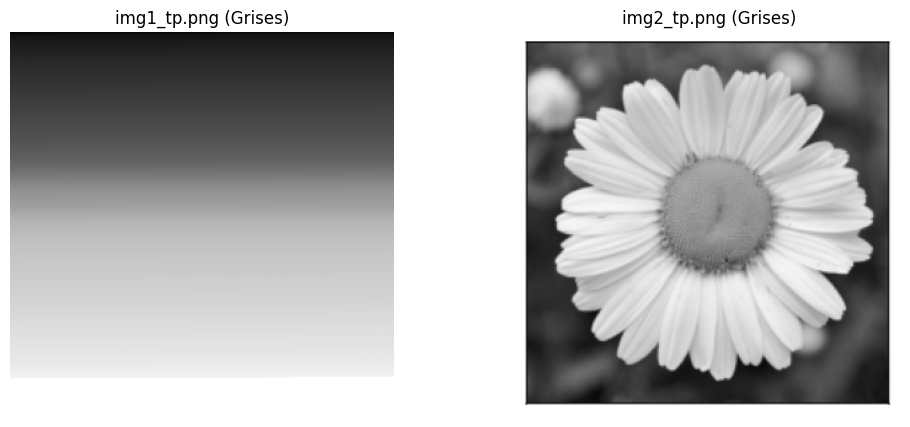

In [18]:
# 1. Leer imágenes en escala de grises
img1 = cv.imread("img1_tp.png", cv.IMREAD_GRAYSCALE)
img2 = cv.imread("img2_tp.png", cv.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img1, cmap='gray')
plt.title('img1_tp.png (Grises)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img2, cmap='gray')
plt.title('img2_tp.png (Grises)')
plt.axis('off')
plt.show()

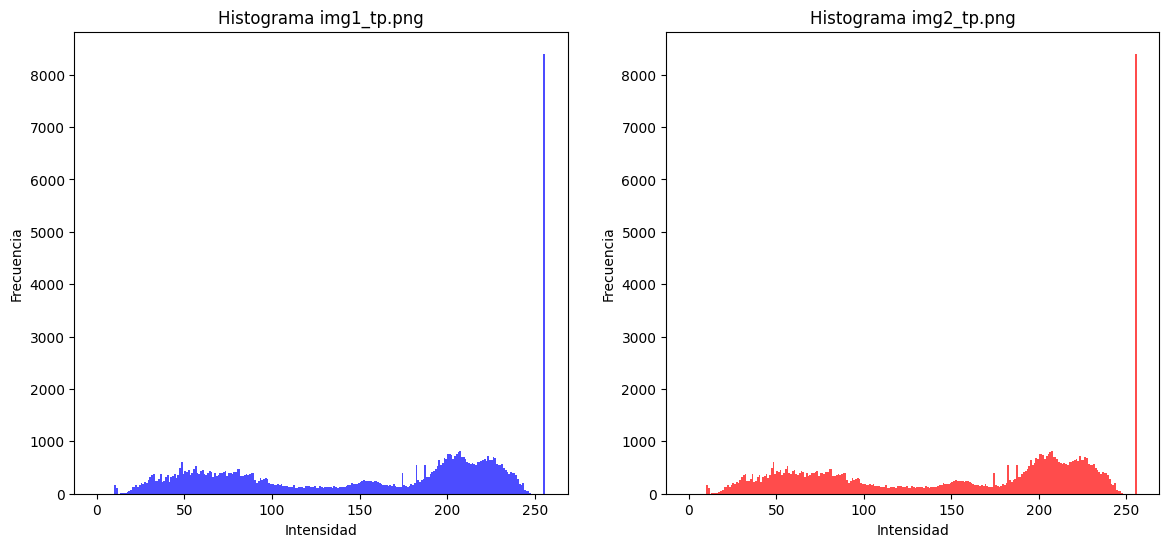

In [19]:
# 2. Graficar histogramas
bins = 256

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.hist(img1.ravel(), bins, range=(0, 256), color='blue', alpha=0.7)
plt.title('Histograma img1_tp.png')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
plt.hist(img2.ravel(), bins, range=(0, 256), color='red', alpha=0.7)
plt.title('Histograma img2_tp.png')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')

plt.show()


Se elige 256 bins para representar la distinta intensidad del gris en cada pixel, desde 0 (negro) hasta 255 (blanco). De esta manera, cada bin representa un nivel de intensidad específico.

En los histogramas observamos que ambas imágenes tienen prácticamente la misma distribución de intensidad de píxeles, aunque visualmente sean completamente distintas. Esto ocurre porque el histograma únicamente contabiliza cuántos píxeles existen de cada intensidad, pero no considera la ubicación espacial de esos píxeles dentro de la imagen. En este caso, la Imagen 1 (el gradiente) y la Imagen 2 (la flor) son visualmente muy diferentes, pero sus histogramas resultan casi idénticos. Esto demuestra que el histograma funciona como un descriptor global y no permite distinguir formas, objetos o escenas.

También se observa que en la intensidad 255 existe un pico muy marcado, con más de 8000 píxeles en ese valor. Esto indica que ambas imágenes poseen grandes regiones saturadas en blanco. En el gradiente corresponde a la banda inferior blanca, mientras que en la imagen de la flor corresponde principalmente a los pétalos o zonas de fondo brillante. Esta concentración de valores hace más difícil analizar detalles finos en otras zonas del histograma.


Para el caso de identificación o clasificación de imágenes, los histogramas pueden ser útiles como features globales simples. Por ejemplo, Podrian servir para clasificar si la imagen esta saturada, si tiene muchos tonos oscuros o claros, o si quisieramos identificar si fue modificada o no.
